In [1]:
# Cell 1 — Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

BASE_PATH = r'D:\Jupyter\MLOps_Gold\\'
DATA_PATH = BASE_PATH + 'data\\'
VISUAL_PATH = BASE_PATH + 'visuals\\'
MODEL_PATH = BASE_PATH + 'models\\'

os.makedirs(VISUAL_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("Setup selesai!")

Setup selesai!


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv(DATA_PATH + 'Dataset.csv', sep=';')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%Y.%m.%d %H:%M')
df = df.set_index('Date')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

print(f"Data berhasil dimuat!")
print(f"Jumlah baris: {len(df):,}")
print(f"Periode: {df.index.min()} s/d {df.index.max()}")

Data berhasil dimuat!
Jumlah baris: 6,789,606
Periode: 2004-06-11 07:18:00 s/d 2026-01-30 23:59:00


In [3]:
# Cell 3 — Cleaning: Asfreq + Fill Gap + Flag
df = df.asfreq('1min')
df['Is Filled'] = df['Close'].isna().astype(int)
df = df.ffill()

print(f"Gap ditangani!")
print(f"Total baris: {len(df):,}")
print(f"Data asli   : {(df['Is Filled'] == 0).sum():,} baris")
print(f"Data filled : {(df['Is Filled'] == 1).sum():,} baris ({(df['Is Filled'].mean()*100):.1f}%)")

Gap ditangani!
Total baris: 11,381,322
Data asli   : 6,789,606 baris
Data filled : 4,591,716 baris (40.3%)


In [4]:
# Cell 4 — Wavelet Denoising
import pywt

def wavelet_denoise(series, wavelet='db4', level=3):
    coeffs = pywt.wavedec(series, wavelet, level=level)
    threshold = np.sqrt(2 * np.log(len(series))) * np.median(np.abs(coeffs[-1])) / 0.6745
    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]
    return pywt.waverec(coeffs_thresh, wavelet)[:len(series)]

df['Close Denoised'] = wavelet_denoise(df['Close'].values)
print("Wavelet Denoising selesai!")
print(df[['Close', 'Close Denoised']].head())

Wavelet Denoising selesai!
                     Close  Close Denoised
Date                                      
2004-06-11 07:18:00  384.0      383.907946
2004-06-11 07:19:00  384.0      383.935006
2004-06-11 07:20:00  384.0      383.945098
2004-06-11 07:21:00  384.0      383.935938
2004-06-11 07:22:00  384.0      383.923136


In [5]:
# Cell 5 — Moving Average
df['MA 5'] = df['Close'].rolling(window=5).mean()
df['MA 10'] = df['Close'].rolling(window=10).mean()
df['MA 15'] = df['Close'].rolling(window=15).mean()
df['MA 30'] = df['Close'].rolling(window=30).mean()
print("Moving Average selesai!")

Moving Average selesai!


In [6]:
# Cell 6 — RSI, MACD, ROC
import ta

df['RSI 14'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()
macd = ta.trend.MACD(close=df['Close'])
df['MACD'] = macd.macd()
df['MACD Signal'] = macd.macd_signal()
df['ROC 10'] = ta.momentum.ROCIndicator(close=df['Close'], window=10).roc()
print("RSI, MACD, ROC selesai!")

RSI, MACD, ROC selesai!


In [7]:
# Cell 7 — ATR & Bollinger Bands
df['ATR 14'] = ta.volatility.AverageTrueRange(
    high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()

bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB Upper'] = bb.bollinger_hband()
df['BB Lower'] = bb.bollinger_lband()
print("ATR & Bollinger Bands selesai!")

ATR & Bollinger Bands selesai!


In [8]:
# Cell 8 — Microstructure
df['HL Range'] = df['High'] - df['Low']
df['OC Range'] = df['Close'] - df['Open']
print("Microstructure selesai!")

Microstructure selesai!


In [9]:
# Cell 9 — Regime Detection (HMM)
from hmmlearn.hmm import GaussianHMM

returns = df['Close'].pct_change().fillna(0).values.reshape(-1, 1)
hmm_model = GaussianHMM(n_components=3, covariance_type='full', n_iter=100, random_state=42)
hmm_model.fit(returns)
df['Market Regime'] = hmm_model.predict(returns)

print("Regime Detection selesai!")
print(df['Market Regime'].value_counts())

Model is not converging.  Current: 84998919.87322569 is not greater than 84998920.00765197. Delta is -0.1344262808561325


Regime Detection selesai!
Market Regime
1    4091207
0    4004316
2    3285799
Name: count, dtype: int64


In [10]:
# Cell 10 — Lag Features & Target
df['Lag 1'] = df['Close'].shift(1)
df['Lag 2'] = df['Close'].shift(2)
df['Lag 3'] = df['Close'].shift(3)
df['Target'] = df['Close'].shift(-1)
print("Lag Features & Target selesai!")

Lag Features & Target selesai!


In [11]:
# Cell 11 — Drop NaN
df = df.dropna()
print(f"Drop NaN selesai!")
print(f"Jumlah baris final: {len(df):,}")
print(f"Jumlah kolom: {len(df.columns)}")
df.head()

Drop NaN selesai!
Jumlah baris final: 11,381,288
Jumlah kolom: 25


,Open,High,Low,Close,Volume,Is Filled,Close Denoised,MA 5,MA 10,MA 15,...,ATR 14,BB Upper,BB Lower,HL Range,OC Range,Market Regime,Lag 1,Lag 2,Lag 3,Target
Date,,,,,,,,,,,,,,,,,,,,,
2004-06-11 07:51:00,383.5,383.5,383.3,383.3,2.0,0,383.331501,383.34,383.43,383.593333,...,0.205723,384.205268,383.084732,0.2,-0.2,2,383.3,383.3,383.3,383.6
2004-06-11 07:52:00,383.6,383.6,383.6,383.6,1.0,0,383.380870,383.36,383.43,383.546667,...,0.212457,384.190968,383.079032,0.0,0.0,2,383.3,383.3,383.3,383.8
2004-06-11 07:53:00,383.8,383.8,383.8,383.8,1.0,0,383.406851,383.46,383.45,383.560000,...,0.211567,384.190968,383.079032,0.0,0.0,2,383.6,383.3,383.3,383.5
2004-06-11 07:54:00,383.6,383.6,383.5,383.5,2.0,0,383.452175,383.50,383.42,383.540000,...,0.217884,384.173534,383.066466,0.1,-0.1,2,383.8,383.6,383.3,383.5
2004-06-11 07:55:00,383.6,383.6,383.5,383.5,2.0,1,383.502951,383.54,383.44,383.520000,...,0.209463,384.154454,383.055546,0.1,-0.1,2,383.5,383.8,383.6,383.5


Korelasi Fitur dengan Target:
Close Denoised    1.000000
Close             1.000000
High              1.000000
Low               1.000000
Lag 1             1.000000
MA 5              1.000000
Open              1.000000
Lag 2             0.999999
MA 10             0.999999
Lag 3             0.999999
MA 15             0.999999
MA 30             0.999998
BB Upper          0.999997
BB Lower          0.999996
ATR 14            0.451536
HL Range          0.412930
Volume            0.226190
Market Regime     0.020566
RSI 14            0.015615
MACD Signal       0.012346
MACD              0.011663
ROC 10            0.002268
OC Range         -0.028770
Is Filled        -0.128169
Name: Target, dtype: float64


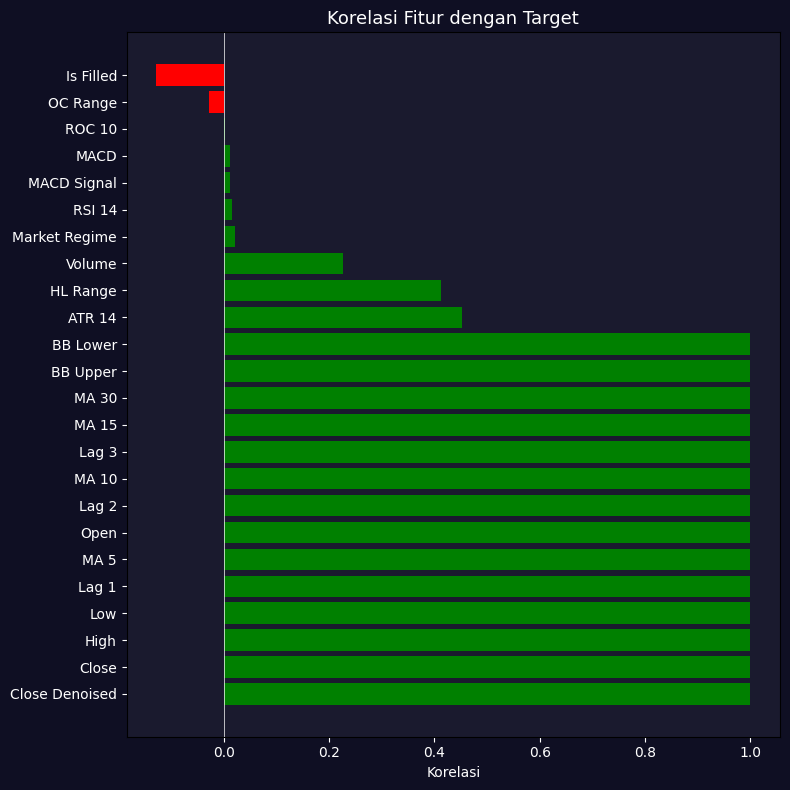

Korelasi selesai!


In [12]:
# Cell 12 — Cek Korelasi Fitur dengan Target
feature_cols = [c for c in df.columns if c != 'Target']

corr_with_target = df[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values(ascending=False)

print("Korelasi Fitur dengan Target:")
print(corr_with_target)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['green' if v > 0 else 'red' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.set_title('Korelasi Fitur dengan Target', color='white', fontsize=13)
ax.set_xlabel('Korelasi', color='white')
ax.axvline(0, color='white', linewidth=0.5)
ax.tick_params(colors='white')
fig.patch.set_facecolor('#0f0f23')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Korelasi selesai!")

In [13]:
# Cell 13 — Adaptive Normalization
cols_to_normalize = [c for c in df.columns if c not in ['Is Filled', 'Market Regime']]

window_size_norm = 1000
df_norm = df.copy()

for col in cols_to_normalize:
    rolling_min = df[col].rolling(window=window_size_norm, min_periods=1).min()
    rolling_max = df[col].rolling(window=window_size_norm, min_periods=1).max()
    df_norm[col] = (df[col] - rolling_min) / (rolling_max - rolling_min + 1e-8)

df_norm = df_norm.dropna()

print(f"Adaptive Normalization selesai!")
print(f"Jumlah baris: {len(df_norm):,}")
print(df_norm[['Close', 'MA 5', 'RSI 14', 'Target']].head())

Adaptive Normalization selesai!
Jumlah baris: 11,381,288
                     Close  MA 5    RSI 14  Target
Date                                              
2004-06-11 07:51:00    0.0   0.0  0.000000     0.0
2004-06-11 07:52:00    1.0   1.0  1.000000     1.0
2004-06-11 07:53:00    1.0   1.0  1.000000     0.0
2004-06-11 07:54:00    0.4   1.0  0.471079     0.0
2004-06-11 07:55:00    0.4   1.0  0.471079     0.0


In [14]:
# Cell 14 — Save Data & Summary
df_norm.to_parquet(DATA_PATH + 'data_clean_normalized.parquet')

print("=" * 50)
print("RINGKASAN DATA SIAP TRAINING")
print("=" * 50)
print(f"\nTotal baris: {len(df_norm):,}")
print(f"Jumlah fitur: {len(feature_cols)}")
print(f"Target: Close 1 menit ke depan (normalized)")
print(f"\nDaftar Fitur ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")
print("\n" + "=" * 50)
print(f"Data disimpan: {DATA_PATH}data_clean_normalized.parquet")
print("=" * 50)

RINGKASAN DATA SIAP TRAINING

Total baris: 11,381,288
Jumlah fitur: 24
Target: Close 1 menit ke depan (normalized)

Daftar Fitur (24):
   1. Open
   2. High
   3. Low
   4. Close
   5. Volume
   6. Is Filled
   7. Close Denoised
   8. MA 5
   9. MA 10
   10. MA 15
   11. MA 30
   12. RSI 14
   13. MACD
   14. MACD Signal
   15. ROC 10
   16. ATR 14
   17. BB Upper
   18. BB Lower
   19. HL Range
   20. OC Range
   21. Market Regime
   22. Lag 1
   23. Lag 2
   24. Lag 3

Data disimpan: D:\Jupyter\MLOps_Gold\\data\data_clean_normalized.parquet
